In [ ]:
!pip install pandas geopandas matplotlib contextily matplotlib-scalebar leafmap -q

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
import leafmap.foliumap as leafmap
import contextily as ctx

In [ ]:
!git clone https://github.com/kondojukushi10-rgb/chennai-service-accessibility-analyzer.git

Cloning into 'chennai-service-accessibility-analyzer'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 67 (delta 18), reused 62 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 17.58 MiB | 30.99 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [ ]:
import os
os.chdir("/content/chennai-service-accessibility-analyzer")

In [ ]:
zones = gpd.read_file("outputs/zones_processed.geojson")
school = gpd.read_file("processed/school_accessibility.geojson")
hospital = gpd.read_file("processed/hospital_accessibility.geojson")
park = gpd.read_file("processed/park_accessibility.geojson")

In [ ]:
# Reproject everything to Web Mercator (needed for basemap)
zones = zones.to_crs(epsg=3857)
school = school.to_crs(epsg=3857)
hospital = hospital.to_crs(epsg=3857)
park = park.to_crs(epsg=3857)

In [ ]:
COLORS = {
    "school": "#1f78b4",
    "hospital": "#e31a1c",
    "park": "#33a02c",
    "roads": "#ff7f00"
}

In [ ]:
def add_map_elements(ax):
    # Scale bar
    scalebar = ScaleBar(1, location='lower left')
    ax.add_artist(scalebar)

    # North arrow
    ax.annotate('N',
                xy=(0.95, 0.95), xytext=(0.95, 0.85),
                arrowprops=dict(facecolor='black', width=5, headwidth=15),
                ha='center', va='center', fontsize=12,
                xycoords=ax.transAxes)

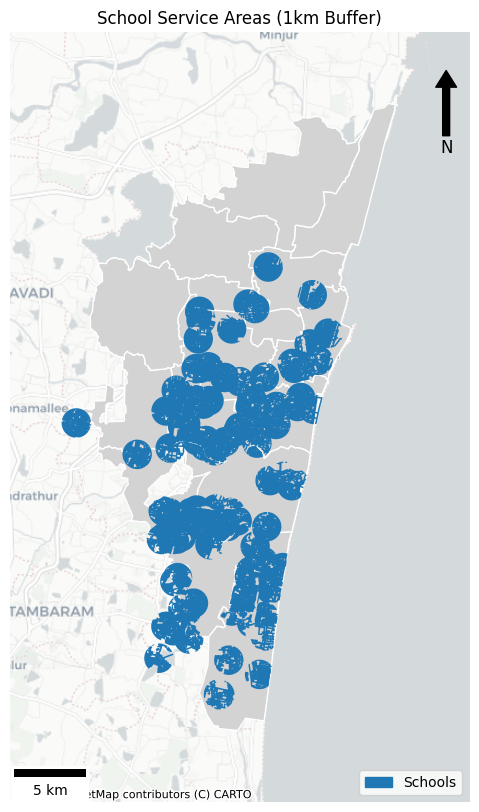

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

zones.plot(ax=ax, color='lightgrey', edgecolor='white')
school.plot(ax=ax, color=COLORS["school"], markersize=10, label="Schools")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

xmin, ymin, xmax, ymax = zones.total_bounds
buffer = 5000  # increase this for more zoom out
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

add_map_elements(ax)

school_patch = mpatches.Patch(color=COLORS["school"], label="Schools")
ax.legend(handles=[school_patch], loc='lower right')

ax.set_title("School Service Areas (1km Buffer)")

ax.axis('off')
plt.savefig("school_service_area.png", dpi=300, bbox_inches='tight')
plt.show()

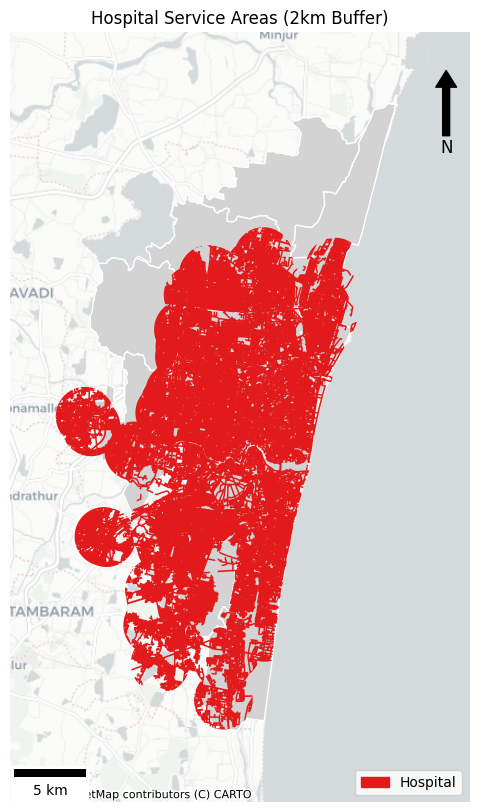

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

zones.plot(ax=ax, color='lightgrey', edgecolor='white')
hospital.plot(ax=ax, color=COLORS["hospital"], markersize=10, label="Hospitals")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

xmin, ymin, xmax, ymax = zones.total_bounds
buffer = 5000  # increase this for more zoom out
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

add_map_elements(ax)

hospital_patch = mpatches.Patch(color=COLORS["hospital"], label="Hospital")
ax.legend(handles=[hospital_patch], loc='lower right')

ax.set_title("Hospital Service Areas (2km Buffer)")

ax.axis('off')
plt.savefig("Hospital_Serive_areas.png", dpi=300, bbox_inches='tight')
plt.show()

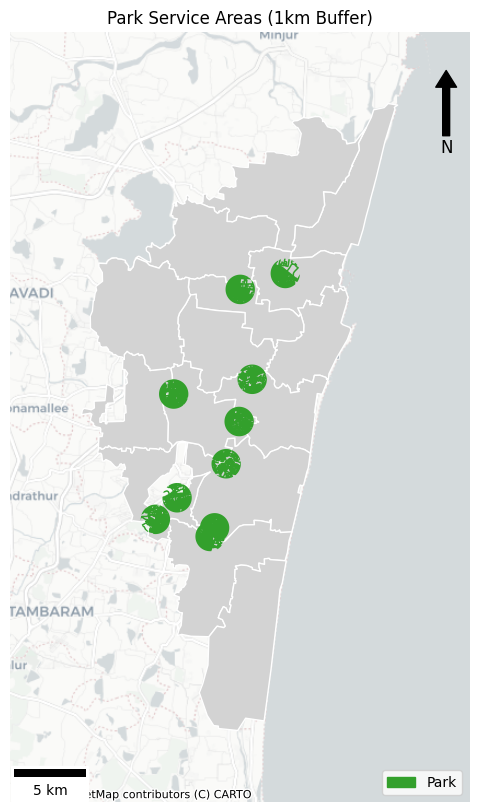

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

zones.plot(ax=ax, color='lightgrey', edgecolor='white')
park.plot(ax=ax, color=COLORS["park"], markersize=10, label="Parks")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

xmin, ymin, xmax, ymax = zones.total_bounds
buffer = 5000  # increase this for more zoom out
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

add_map_elements(ax)

park_patch = mpatches.Patch(color=COLORS["park"], label="Park")
ax.legend(handles=[park_patch], loc='lower right')

ax.set_title("Park Service Areas (1km Buffer)")

ax.axis('off')
plt.savefig("Park_service_area.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import leafmap.foliumap as leafmap

m = leafmap.Map()

m.add_gdf(
    zones.to_crs(4326),
    layer_name="Zones",
    style={
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.1
    }
)
m.add_gdf(
    school.to_crs(4326),
    layer_name="School",
    style={
        "color": COLORS["school"],
        "fillColor": COLORS["school"],
        "weight": 1	,
        "fillOpacity": 1
    }
)

m.add_layer_control()
m

In [ ]:
m1 = leafmap.Map()
m1.add_gdf(
    zones.to_crs(4326),
    layer_name="Zones",
    style={
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.1
    }
)
m1.add_gdf(
    hospital.to_crs(4326),
    layer_name="Hospitals",
    style={
        "color": "red",
        "fillColor": "red",
        "weight": 1	,
        "fillOpacity": 1
    }
)

m1.add_layer_control()
m1

In [ ]:
m2 = leafmap.Map()
m2.add_gdf(
    zones.to_crs(4326),
    layer_name="Zones",
    style={
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.1
    }
)
m2.add_gdf(
    park.to_crs(4326),
    layer_name="Parks",
    style={
        "color": "green",
        "fillColor": "green",
        "weight": 1	,
        "fillOpacity": 1
    }
)

m2.add_layer_control()
m2

In [ ]:
zones.head()

,id,Zone_No,Area,Population,Name,Zone_name,Projec_Pop,No_of_stop,Route_leng,Buffer_are,...,P500,P500_Perce,zone_area_sqm,school_access_area,school_access_percentage,hospital_access_area,hospital_access_percentage,park_access_area,park_access_percentage,geometry
0,0,I,25.7508,286063,Zone_I,THIRUVOTRIYUR,314533,20,45.683333,8.580296,...,104803.979985,33.320504,2.575084e+07,0.000000e+00,0.000000,1.768290e+06,6.866922,0.000000e+00,0.000000,"POLYGON ((8940933.609 1486220.144, 8941667.57 ..."
1,0,II,42.6893,89170,Zone_II,MANALI,98045,3,27.241155,1.714721,...,3938.219140,4.016747,4.268930e+07,0.000000e+00,0.000000,5.286710e+05,1.238416,0.000000e+00,0.000000,"MULTIPOLYGON (((8940426.598 1484993.52, 894042..."
2,0,III,31.4220,191453,Zone_III,MADHAVARAM,210507,19,41.285224,11.091531,...,74306.054690,35.298615,3.142197e+07,4.820329e+03,0.015341,1.165265e+07,37.084404,8.402249e+05,2.674004,"POLYGON ((8928812.198 1479683.749, 8929447.911..."
3,0,IV,20.4106,697271,Zone_IV,TONDIARPET,766667,11,41.884743,7.488912,...,281299.986772,36.691287,2.041064e+07,5.473202e+06,26.815438,1.714478e+07,83.999232,2.497986e+06,12.238648,"POLYGON ((8939004.83 1476065.224, 8938749.727 ..."
4,0,V,21.5580,619437,Zone_V,ROYAPURAM,681086,62,83.420418,16.295310,...,514820.819000,75.588225,2.155797e+07,1.209292e+07,56.094898,1.911422e+07,88.664275,2.706016e+03,0.012552,"POLYGON ((8938972.227 1473600.791, 8939139.163..."


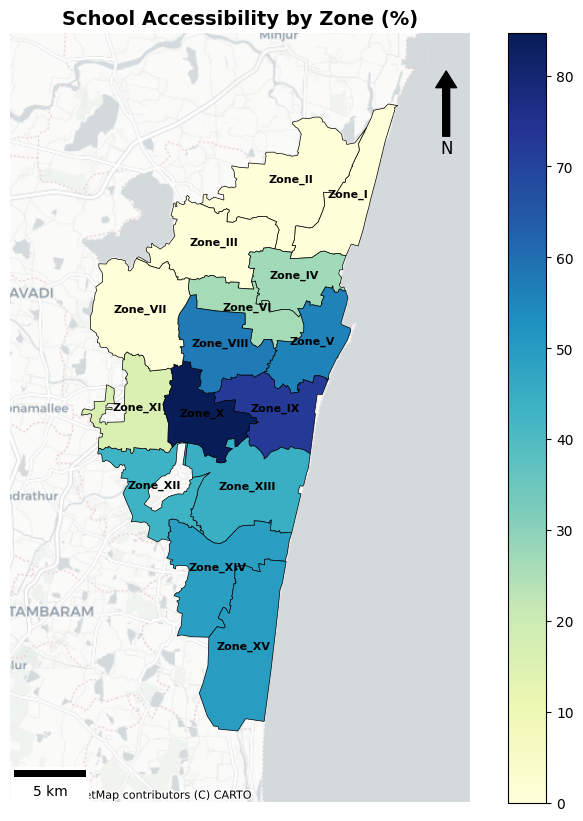

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Choropleth ----
zones.plot(
    column="school_access_percentage",
    cmap="YlGnBu",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---- Basemap ----
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

xmin, ymin, xmax, ymax = zones.total_bounds
buffer = 5000  # increase this for more zoom out
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# ---- Add Zone Labels ----
for idx, row in zones.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    ax.text(
        x, y,
        row["Name"],
        fontsize=8,
        ha='center',
        color='black',
        weight='bold'
    )

add_map_elements(ax)

ax.set_title("School Accessibility by Zone (%)", fontsize=14, fontweight='bold')

ax.axis('off')
plt.savefig("school_accessibility_map.png", dpi=300, bbox_inches='tight')
plt.show()

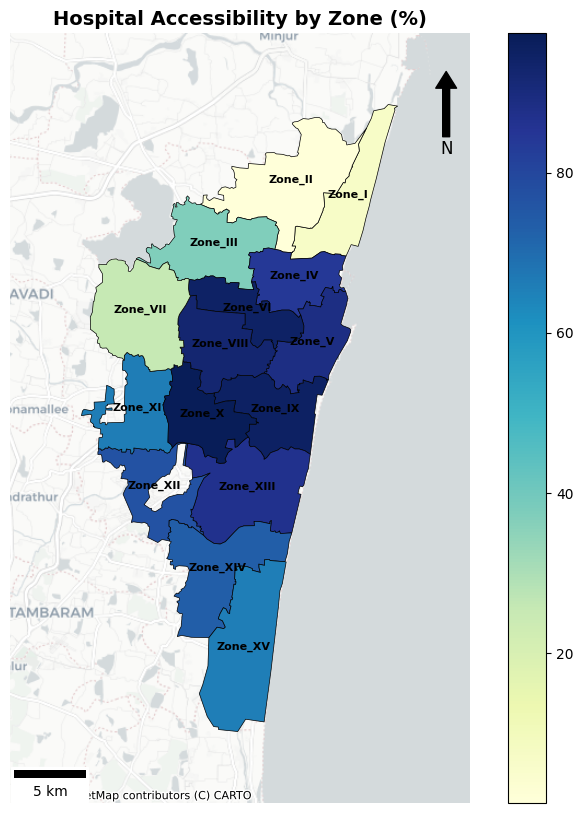

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Choropleth ----
zones.plot(
    column="hospital_access_percentage",
    cmap="YlGnBu",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---- Basemap ----
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

xmin, ymin, xmax, ymax = zones.total_bounds
buffer = 5000  # increase this for more zoom out
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# ---- Add Zone Labels ----
for idx, row in zones.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    ax.text(
        x, y,
        row["Name"],
        fontsize=8,
        ha='center',
        color='black',
        weight='bold'
    )

add_map_elements(ax)

ax.set_title("Hospital Accessibility by Zone (%)", fontsize=14, fontweight='bold')

ax.axis('off')
plt.savefig("Hospital_accessibility_map.png", dpi=300, bbox_inches='tight')
plt.show()

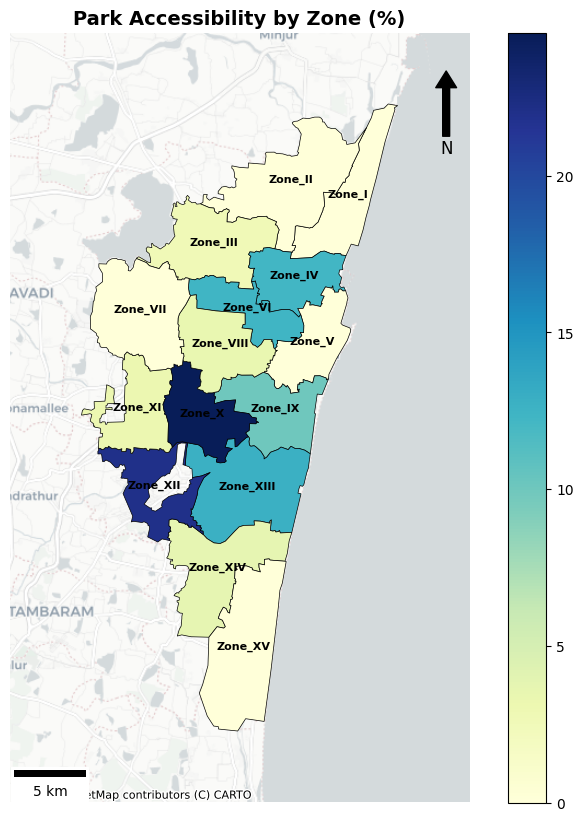

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Choropleth ----
zones.plot(
    column="park_access_percentage",
    cmap="YlGnBu",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---- Basemap ----
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

xmin, ymin, xmax, ymax = zones.total_bounds
buffer = 5000  # increase this for more zoom out
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# ---- Add Zone Labels ----
for idx, row in zones.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    ax.text(
        x, y,
        row["Name"],
        fontsize=8,
        ha='center',
        color='black',
        weight='bold'
    )

add_map_elements(ax)

ax.set_title("Park Accessibility by Zone (%)", fontsize=14, fontweight='bold')

ax.axis('off')
plt.savefig("park_accessibility_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
zones["combined_access_percentage"] = (
    zones["school_access_percentage"] * 0.4 +
    zones["hospital_access_percentage"] * 0.4 +
    zones["park_access_percentage"] * 0.2
)

In [ ]:
zones[["Zone_name", "combined_access_percentage"]].head()

,Zone_name,combined_access_percentage
0,THIRUVOTRIYUR,2.746769
1,MANALI,0.495366
2,MADHAVARAM,15.374699
3,TONDIARPET,46.773597
4,ROYAPURAM,57.906180


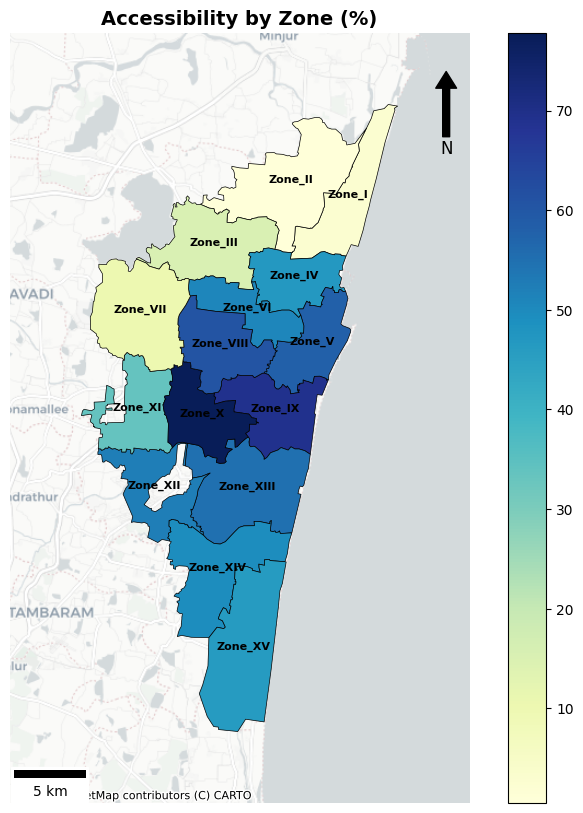

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Choropleth ----
zones.plot(
    column="combined_access_percentage",
    cmap="YlGnBu",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---- Basemap ----
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

xmin, ymin, xmax, ymax = zones.total_bounds
buffer = 5000  # increase this for more zoom out
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# ---- Add Zone Labels ----
for idx, row in zones.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    ax.text(
        x, y,
        row["Name"],
        fontsize=8,
        ha='center',
        color='black',
        weight='bold'
    )

add_map_elements(ax)

ax.set_title("Accessibility by Zone (%)", fontsize=14, fontweight='bold')
plt.savefig("accessibility_map.png", dpi=300, bbox_inches='tight')
ax.axis('off')

plt.show()

In [ ]:
zones["combined_access_percentage"] = (
    zones["combined_access_percentage"] - zones["combined_access_percentage"].min()
) / (
    zones["combined_access_percentage"].max() - zones["combined_access_percentage"].min()
)

zones["access_level"] = pd.qcut(
    zones["combined_access_percentage"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

final_table = zones[[
    "Zone_name",
    "combined_access_percentage",
    "access_level"
]].copy()

final_table["combined_access_percentage"] = final_table["combined_access_percentage"].round(3)

final_table = final_table.sort_values(
    by="combined_access_percentage",
    ascending=False
).reset_index(drop=True)

print(final_table.to_string(index=False))

final_table.to_csv("/content/combined_access_table.csv", index=False)

        Zone_name  combined_access_percentage access_level
      KODAMBAKKAM                       1.000         High
        TEYNAMPET                       0.888         High
       ANNA NAGAR                       0.779         High
        ROYAPURAM                       0.743         High
            ADYAR                       0.707         High
          ALANDUR                       0.670       Medium
THIRU-VI-KA NAGAR                       0.651       Medium
        PERUNGUDI                       0.633       Medium
       TONDIARPET                       0.599       Medium
   SOZHANGANALLUR                       0.592       Medium
   VALASARAVAKKAM                       0.427          Low
       MADHAVARAM                       0.193          Low
         AMBATTUR                       0.125          Low
    THIRUVOTRIYUR                       0.029          Low
           MANALI                       0.000          Low
